In [82]:
import pandas as pd
import numpy as np

In [83]:
import sklearn

In [84]:
df=pd.read_csv("Automobile_data-selected-columns.csv")

In [85]:
df

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4
...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1


In [86]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4


In [87]:
df.tail()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1
204,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1


In [88]:
df.shape

(205, 10)

In [89]:
df.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base'],
      dtype='str')

In [90]:
df.nunique()

symboling             6
normalized-losses    52
make                 22
fuel-type             2
aspiration            2
num-of-doors          3
body-style            5
drive-wheels          3
engine-location       2
wheel-base           53
dtype: int64

In [91]:
df['symboling'].unique()

array([ 3,  1,  2,  0, -1, -2])

In [92]:
df['normalized-losses'].unique()

<StringArray>
[  '?', '164', '158', '192', '188', '121',  '98',  '81', '118', '148', '110',
 '145', '137', '101',  '78', '106',  '85', '107', '104', '113', '150', '129',
 '115',  '93', '142', '161', '153', '125', '128', '122', '103', '168', '108',
 '194', '231', '119', '154',  '74', '186',  '83', '102',  '89',  '87',  '77',
  '91', '134',  '65', '197',  '90',  '94', '256',  '95']
Length: 52, dtype: str

In [93]:
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
dtype: int64

In [94]:
for i in df['normalized-losses']:
    if not(i.isdigit()):
        print(i,end='')

?????????????????????????????????????????

In [95]:
# replace ? with null values

In [96]:
# df['normalized-losses'].replace('?',np.nan,inplace=True)
df['normalized-losses']=df['normalized-losses'].replace('?',np.nan,inplace=True)

C:\Users\swaru\AppData\Local\Temp\ipykernel_24768\2275960410.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['normalized-losses']=df['normalized-losses'].replace('?',np.nan,inplace=True)


In [97]:
df['normalized-losses'].dtype

<StringDtype(storage='python', na_value=nan)>

In [98]:
df.isnull().sum()

symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          0
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
dtype: int64

In [99]:
# convert to float

In [100]:
df['normalized-losses']=df['normalized-losses'].astype("float64")

In [101]:
df['normalized-losses'].dtype

dtype('float64')

In [102]:
# find mean of normalized-losses

In [103]:
m=df['normalized-losses'].mean()

In [104]:
m

np.float64(122.0)

In [105]:
# replace all nan of normalized losses with mean

In [106]:
df['normalized-losses']=df['normalized-losses'].fillna(m)

In [107]:
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
dtype: int64

In [108]:
# Outliers

In [109]:
import seaborn as sns

<Axes: xlabel='wheel-base'>

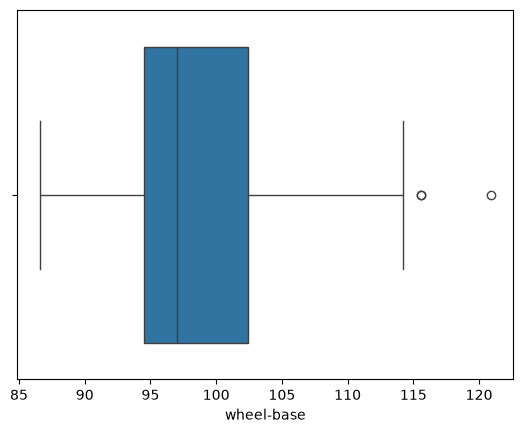

In [110]:
sns.boxplot(data=df,x=df['wheel-base'])

In [111]:
q1=np.percentile(df['wheel-base'],25)

In [112]:
q1

np.float64(94.5)

In [113]:
q2=np.percentile(df['wheel-base'],50)
q3=np.percentile(df['wheel-base'],75)

In [114]:
q2

np.float64(97.0)

In [115]:
q3

np.float64(102.4)

In [116]:
iqr=q3-q1

In [117]:
iqr

np.float64(7.900000000000006)

In [118]:
uw=q3+1.5*iqr

In [119]:
uw

np.float64(114.25000000000001)

In [120]:
lw=q1-1.5*iqr

In [121]:
lw

np.float64(82.64999999999999)

In [122]:
# remove outliers

<Axes: xlabel='wheel-base', ylabel='make'>

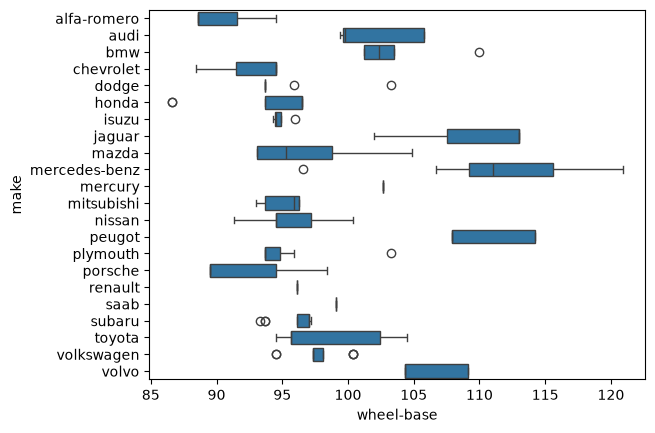

In [123]:
sns.boxplot(data=df,x=df['wheel-base'],y='make')

In [124]:
df[(df['make']=="bmw") & (df['wheel-base']>105)]

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base
17,0,122.0,bmw,gas,std,four,sedan,rwd,front,110.0


In [125]:
df.drop(17,inplace=True)

In [126]:
for make in df['make'].unique():
    wheel_base=df[df['make']==make]['wheel-base']
    # print(make,wheel_base)
    q1=np.percentile(wheel_base,25)
    q3=np.percentile(wheel_base,75)
    iqr=q3-q1
    uw=q3+1.5*iqr
    index=wheel_base[wheel_base>uw].index
    if len(index)!=0:
        print(make,index)


dodge Index([28, 29], dtype='int64')
isuzu Index([46], dtype='int64')
plymouth Index([123], dtype='int64')
volkswagen Index([191, 192, 193], dtype='int64')


In [127]:
# now drop index which is greter than upper limit(which is outlier)

In [128]:
for make in df['make'].unique():
    wheel_base=df[df['make']==make]['wheel-base']
    # print(make,wheel_base)
    q1=np.percentile(wheel_base,25)
    q3=np.percentile(wheel_base,75)
    iqr=q3-q1
    uw=q3+1.5*iqr
    index=wheel_base[wheel_base>uw].index
    if len(index)!=0:
        df.drop(index,inplace=True)

<Axes: xlabel='wheel-base', ylabel='make'>

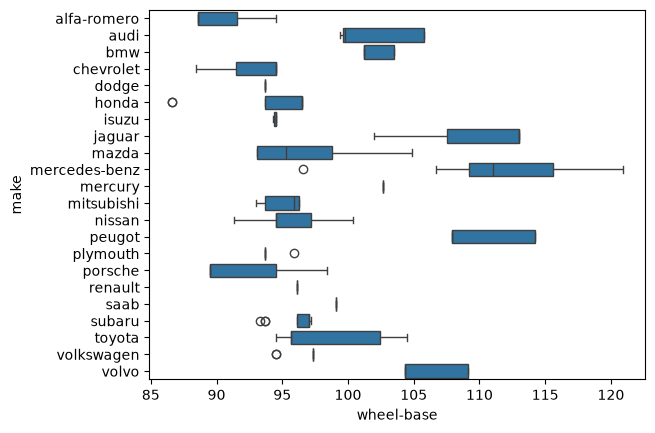

In [129]:
sns.boxplot(x='wheel-base',y='make',data=df)

In [130]:
for make in df['make'].unique():
    wheel_base=df[df['make']==make]['wheel-base']
    # print(make,wheel_base)
    q1=np.percentile(wheel_base,25)
    q3=np.percentile(wheel_base,75)
    iqr=q3-q1
    lw=q1-1.5*iqr
    index=wheel_base[wheel_base<lw].index
    if len(index)!=0:
        df.drop(index,inplace=True)

<Axes: xlabel='wheel-base', ylabel='make'>

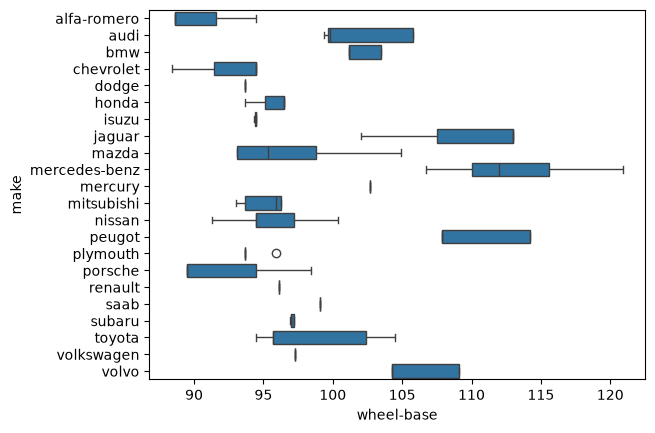

In [131]:
sns.boxplot(x='wheel-base',y='make',data=df)

In [132]:
# encoding in python = used to covert categorical data into numerical
# we have two types of Encoding
# 1)one-hot EncodingWarning
# 2)lable/ordinal encoding

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [134]:
df['wheel-base']=df['wheel-base'].astype("float64")

In [135]:
num_data=df.select_dtypes(["Int64",'float64'])

In [136]:
num_data

,symboling,normalized-losses,wheel-base
0,3,122.0,88.6
1,3,122.0,88.6
2,1,122.0,94.5
3,2,164.0,99.8
4,2,164.0,99.4
...,...,...,...
200,-1,95.0,109.1
201,-1,95.0,109.1
202,-1,95.0,109.1
203,-1,95.0,109.1


In [137]:
cat_data=df.select_dtypes("object")

C:\Users\swaru\AppData\Local\Temp\ipykernel_24768\1556396581.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_data=df.select_dtypes("object")


In [138]:
cat_data

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location
0,alfa-romero,gas,std,two,convertible,rwd,front
1,alfa-romero,gas,std,two,convertible,rwd,front
2,alfa-romero,gas,std,two,hatchback,rwd,front
3,audi,gas,std,four,sedan,fwd,front
4,audi,gas,std,four,sedan,4wd,front
...,...,...,...,...,...,...,...
200,volvo,gas,std,four,sedan,rwd,front
201,volvo,gas,turbo,four,sedan,rwd,front
202,volvo,gas,std,four,sedan,rwd,front
203,volvo,diesel,turbo,four,sedan,rwd,front


<Axes: xlabel='count', ylabel='make'>

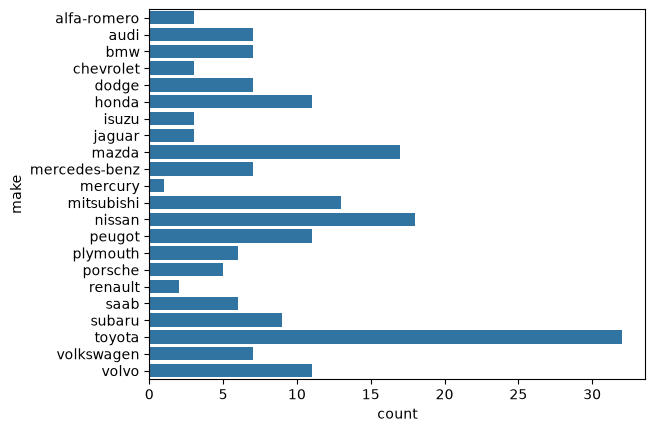

In [139]:
sns.countplot(cat_data['make'])

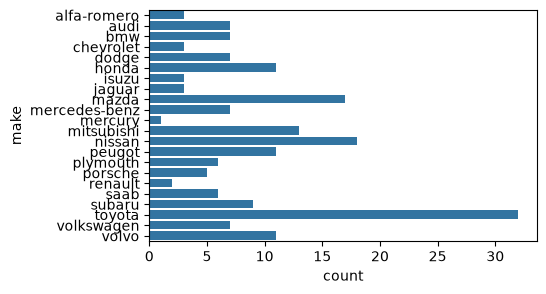

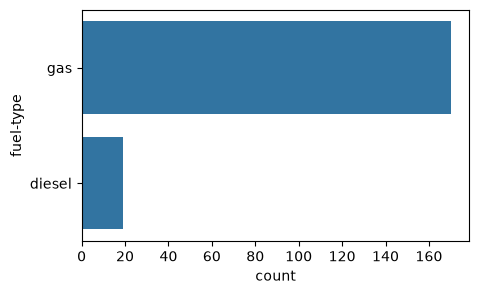

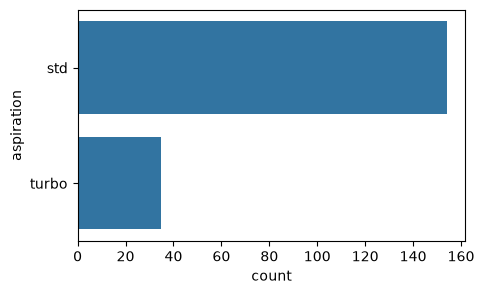

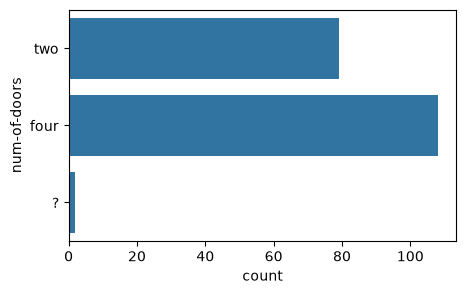

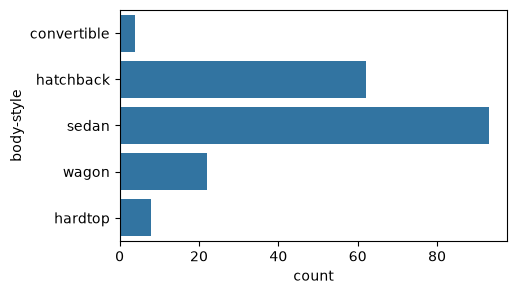

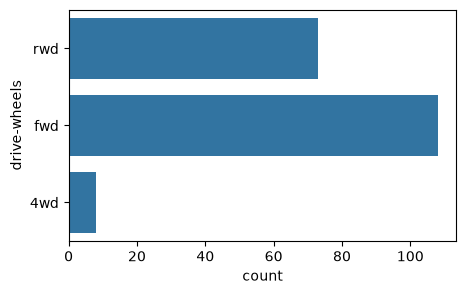

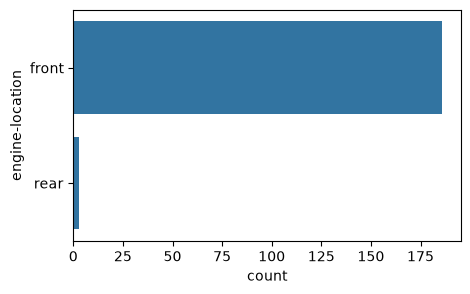

In [140]:
for i in cat_data:
    plt.figure(figsize=(5,3))
    sns.countplot(cat_data[i])

In [141]:
# One hot encoding

In [142]:
cat_data['body-style'].head()

0    convertible
1    convertible
2      hatchback
3          sedan
4          sedan
Name: body-style, dtype: str

In [143]:
pd.get_dummies(df['body-style'],dtype='int')

,convertible,hardtop,hatchback,sedan,wagon
0,1,0,0,0,0
1,1,0,0,0,0
2,0,0,1,0,0
3,0,0,0,1,0
4,0,0,0,1,0
...,...,...,...,...,...
200,0,0,0,1,0
201,0,0,0,1,0
202,0,0,0,1,0
203,0,0,0,1,0


In [144]:
# label encoding

In [145]:
from sklearn.preprocessing import LabelEncoder

In [146]:
le=LabelEncoder()

In [147]:
le.fit_transform(df['body-style'])

array([0, 0, 2, 3, 3, 3, 3, 4, 3, 2, 3, 3, 3, 3, 3, 3, 3, 2, 2, 3, 2, 2,
       2, 2, 3, 3, 3, 2, 2, 2, 3, 4, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       2, 2, 2, 3, 3, 2, 2, 2, 2, 2, 3, 2, 3, 3, 2, 3, 3, 3, 4, 1, 3, 3,
       3, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3,
       2, 3, 4, 1, 2, 3, 3, 4, 3, 2, 2, 2, 3, 3, 4, 4, 3, 3, 4, 4, 3, 3,
       3, 2, 2, 2, 3, 3, 2, 2, 1, 1, 0, 2, 4, 2, 2, 3, 2, 3, 2, 3, 3, 3,
       3, 3, 3, 4, 4, 4, 4, 2, 2, 2, 4, 4, 4, 3, 2, 3, 2, 3, 2, 3, 3, 2,
       3, 2, 1, 1, 2, 1, 2, 0, 3, 3, 2, 3, 2, 2, 2, 3, 4, 3, 3, 3, 3, 3,
       3, 3, 3, 4, 3, 4, 3, 4, 3, 3, 3, 3, 3])

In [148]:
cat_data['body-style']=le.fit_transform(cat_data['body-style'])

In [149]:
cat_data

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location
0,alfa-romero,gas,std,two,0,rwd,front
1,alfa-romero,gas,std,two,0,rwd,front
2,alfa-romero,gas,std,two,2,rwd,front
3,audi,gas,std,four,3,fwd,front
4,audi,gas,std,four,3,4wd,front
...,...,...,...,...,...,...,...
200,volvo,gas,std,four,3,rwd,front
201,volvo,gas,turbo,four,3,rwd,front
202,volvo,gas,std,four,3,rwd,front
203,volvo,diesel,turbo,four,3,rwd,front


In [150]:
for col in cat_data:
    le=LabelEncoder()
    cat_data[col]=le.fit_transform(cat_data[col])

In [151]:
cat_data

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location
0,0,1,0,2,0,2,0
1,0,1,0,2,0,2,0
2,0,1,0,2,2,2,0
3,1,1,0,1,3,1,0
4,1,1,0,1,3,0,0
...,...,...,...,...,...,...,...
200,21,1,0,1,3,2,0
201,21,1,1,1,3,2,0
202,21,1,0,1,3,2,0
203,21,0,1,1,3,2,0


In [152]:
# under numericval data we have to take care of skewness and scaling 

# if we have to check skewness of numerical data then here we are going to create distplot

In [161]:
num_data

,symboling,normalized-losses,wheel-base
0,3,122.0,88.6
1,3,122.0,88.6
2,1,122.0,94.5
3,2,164.0,99.8
4,2,164.0,99.4
...,...,...,...
200,-1,95.0,109.1
201,-1,95.0,109.1
202,-1,95.0,109.1
203,-1,95.0,109.1


<Axes: xlabel='wheel-base', ylabel='Count'>

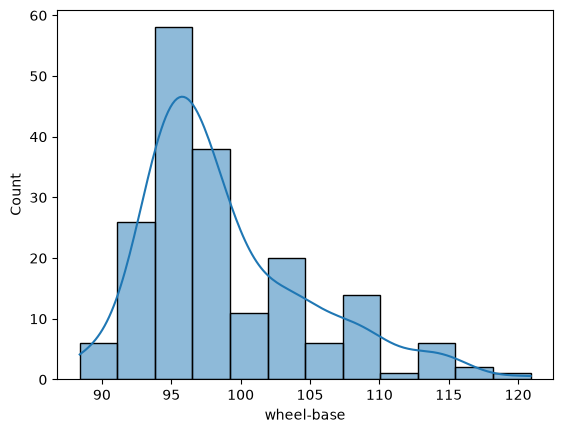

In [154]:
plt.figure()
sns.histplot(num_data['wheel-base'],kde=True)

In [155]:
from scipy.stats import skew

In [162]:
skew(num_data['wheel-base'])

np.float64(1.1220221196396751)

0.250838232384667
0.6263370866060868
1.1220221196396751


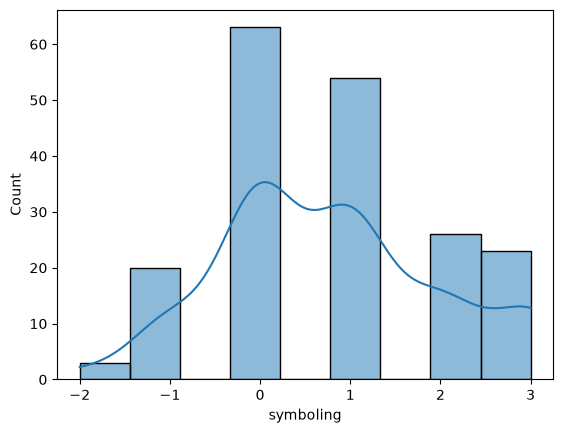

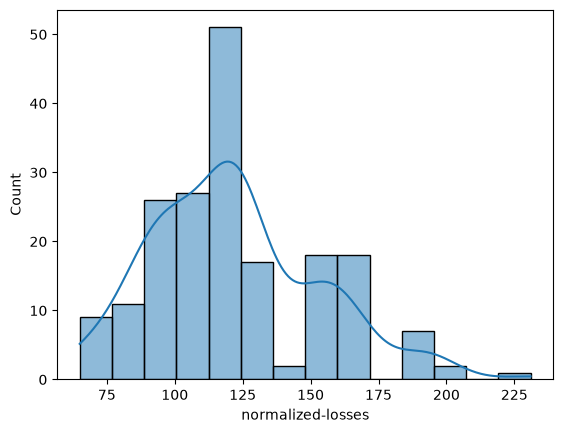

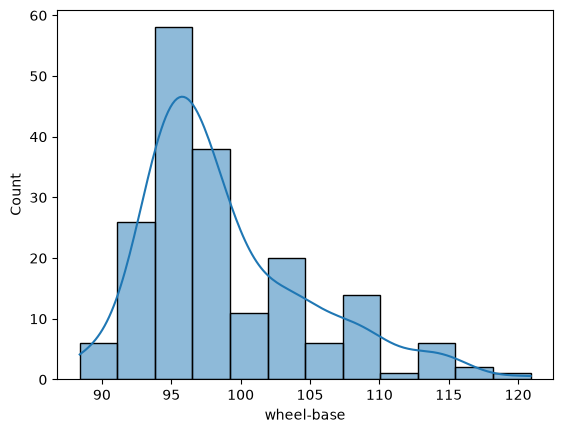

In [157]:
for col in num_data:
    plt.figure()
    sns.histplot(num_data[col],kde=True)
    print(skew(num_data[col]))

In [158]:
# reduce the skewness of wheel_base

In [159]:
# SQRT function

C:\Users\swaru\AppData\Local\Temp\ipykernel_24768\1369791273.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.sqrt(num_data['wheel-base']))


skewness 1.0592554553268418


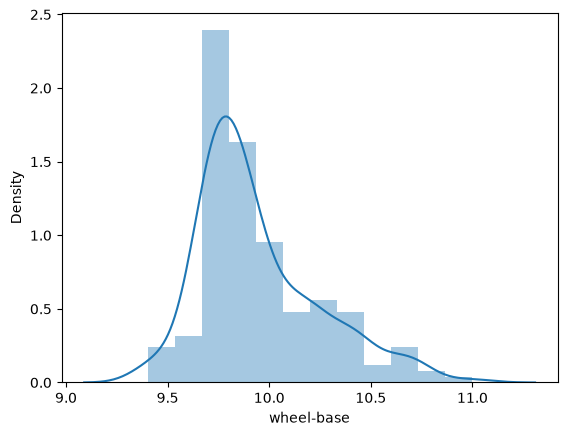

In [164]:
plt.figure()
sns.distplot(np.sqrt(num_data['wheel-base']))
print("skewness",np.sqrt(skew(num_data['wheel-base'])))

C:\Users\swaru\AppData\Local\Temp\ipykernel_24768\3794307145.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log(num_data['wheel-base']))


skewness 0.11513252138004064


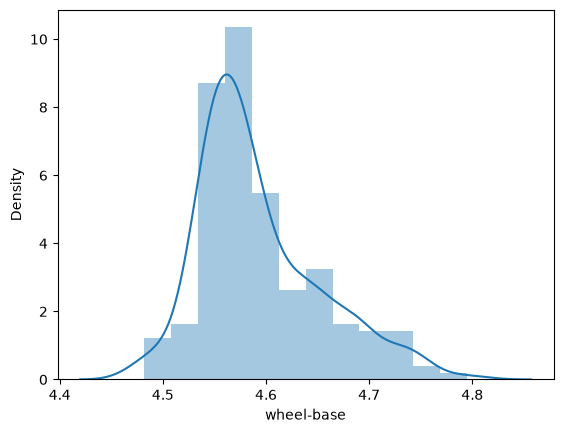

In [165]:
plt.figure()
sns.distplot(np.log(num_data['wheel-base']))
print("skewness",np.log(skew(num_data['wheel-base'])))

In [ ]:
# scaling
# we have two types 0f scaling
# 1)Min-max scaler
# 2)Standard scaler

In [166]:
# 1)Min-max scaler

In [167]:
from sklearn.preprocessing import MinMaxScaler

In [168]:
mm=MinMaxScaler()

In [170]:
mm.fit_transform(num_data[['wheel-base']])

array([[0.00615385],
       [0.00615385],
       [0.18769231],
       [0.35076923],
       [0.33846154],
       [0.35076923],
       [0.53538462],
       [0.53538462],
       [0.53538462],
       [0.34153846],
       [0.39384615],
       [0.39384615],
       [0.39384615],
       [0.39384615],
       [0.46461538],
       [0.46461538],
       [0.46461538],
       [0.        ],
       [0.18769231],
       [0.18769231],
       [0.16307692],
       [0.16307692],
       [0.16307692],
       [0.16307692],
       [0.16307692],
       [0.16307692],
       [0.16307692],
       [0.16307692],
       [0.16307692],
       [0.16307692],
       [0.24923077],
       [0.24923077],
       [0.24923077],
       [0.24923077],
       [0.24923077],
       [0.24923077],
       [0.24923077],
       [0.24923077],
       [0.18153846],
       [0.18769231],
       [0.18769231],
       [0.75692308],
       [0.75692308],
       [0.41846154],
       [0.14461538],
       [0.14461538],
       [0.14461538],
       [0.144

In [171]:
# standardscaler

In [172]:
# standard scaler is the process which we have already learned
# here the formula of standard scaler is

# # ss=(x-mu)/std dev

In [173]:
from sklearn.preprocessing import StandardScaler

In [174]:
ss=StandardScaler()

In [176]:
scaled_data=ss.fit_transform(num_data[['wheel-base']])

In [177]:
scaled_data

array([[-1.72262436],
       [-1.72262436],
       [-0.73780076],
       [ 0.14687128],
       [ 0.08010358],
       [ 0.14687128],
       [ 1.1483868 ],
       [ 1.1483868 ],
       [ 1.1483868 ],
       [ 0.0967955 ],
       [ 0.38055823],
       [ 0.38055823],
       [ 0.38055823],
       [ 0.38055823],
       [ 0.76447252],
       [ 0.76447252],
       [ 0.76447252],
       [-1.75600821],
       [-0.73780076],
       [-0.73780076],
       [-0.87133617],
       [-0.87133617],
       [-0.87133617],
       [-0.87133617],
       [-0.87133617],
       [-0.87133617],
       [-0.87133617],
       [-0.87133617],
       [-0.87133617],
       [-0.87133617],
       [-0.40396226],
       [-0.40396226],
       [-0.40396226],
       [-0.40396226],
       [-0.40396226],
       [-0.40396226],
       [-0.40396226],
       [-0.40396226],
       [-0.77118461],
       [-0.73780076],
       [-0.73780076],
       [ 2.35020542],
       [ 2.35020542],
       [ 0.51409364],
       [-0.97148772],
       [-0